<a href="https://colab.research.google.com/github/vorobieva/pedrelli_2025/blob/main/plot_data/plot_heatmaps_and_SDS_PAGE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import struct
import os
import glob
from scipy.optimize import curve_fit
from numpy import pi, r_
from scipy import optimize
import seaborn as sns

%matplotlib inline

In [ ]:
#@title Mount google drive
from google.colab import drive
drive.mount('/content/google_drive')

Mounted at /content/google_drive


In [ ]:
pathWD="/content/google_drive/MyDrive/data_analysis/"

In [ ]:
f=pathWD+'SSM_ddg.xlsx'

ddG = pd.read_excel(open(f, 'rb'), header=0, index_col=0)
ddG

,6,7,8,9,10,11,12,13,14,15,16
G,0.000000,7.534000,12.487000,12.028000,7.192000,17.041333,8.040,11.550000,10.144,0.000000,9.989667
P,56.209000,29.993000,27.311000,14.465000,5.565000,18.270000,12.634,15.781000,12.355,1.517667,20.265000
E,5.212000,6.575000,4.055000,5.331000,2.452000,18.859667,2.320,9.018000,5.447,7.832000,4.954333
D,3.598333,6.669000,7.926000,9.467000,4.420000,17.367333,4.575,11.898000,6.389,5.013000,8.582000
R,4.650000,7.560000,4.456333,5.272000,2.207000,11.794333,1.609,5.452000,3.845,5.106000,5.062000
K,4.157000,8.117333,3.789000,7.954000,1.712000,14.699000,1.783,5.125000,3.227,6.129000,5.629000
H,3.591000,1.776667,3.214000,4.176000,1.607333,8.452000,1.897,8.814667,4.459,-0.699000,3.072000
Q,3.652667,4.523000,3.308000,4.604000,2.413000,14.510667,1.755,4.542333,2.872,1.593000,4.418000
N,2.629000,4.796000,6.046000,7.028000,2.915000,13.216000,2.713,7.795000,5.334,1.240000,5.347000
T,4.513000,0.000000,4.116000,4.514000,3.216000,12.361000,1.455,4.060000,2.468,1.772333,4.795667


In [ ]:
labels=ddG.copy()
labels = np.where(labels == 0.0, "*", "")
labels

array([['*', '', '', '', '', '', '', '', '', '*', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '*', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '*', '', '', '', '', '*'],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '*', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '*', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '*', '', '*', '

In [ ]:
labels=ddG.copy()
labels = np.where(labels == 0.0, "*", "")
labels

array([['*', '', '', '', '', '', '', '', '', '*', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '*', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '*', '', '', '', '', '*'],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '*', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '*', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '*', '', '*', '

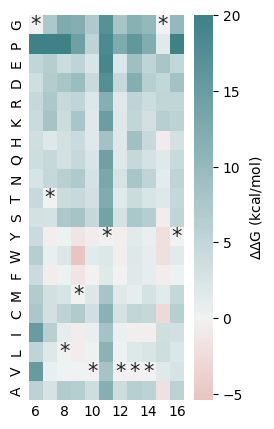

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

#vcenter = 0
#vmin, vmax = ddG.values.min(), ddG.values.max()
#normalize = mcolors.TwoSlopeNorm(vcenter=vcenter, vmin=vmin, vmax=vmax)
#colormap = cm.RdBu

#sns.heatmap(data=ddG, norm=normalize, cmap=colormap)

#scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=colormap)
#scalarmappaple.set_array(y)
#fig.colorbar(scalarmappaple)


fig, ax = plt.subplots(figsize=(2.5, 5))
#sns.heatmap(data=ddG, annot=labels, fmt="s", vmax=20, center= 0, cmap= 'coolwarm')
sns.heatmap(data=ddG, annot=labels, fmt="s", center= 0, vmax=20, cmap=sns.diverging_palette(15, 200, as_cmap=True), annot_kws={"size": 15}, cbar_kws={'label': '$\Delta$$\Delta$G (kcal/mol)'})
plt.tick_params(length=0)

plt.show()


In [ ]:
fr=pathWD+'heatmap_LLR_TMB2.17_esm3_sm_open_v0.csv'

ddGr = pd.read_csv(open(fr, 'rb'), index_col=0)
ddGr

,1,2,3,4,5,6,7,8,9,10,...,115,116,117,118,119,120,121,122,123,124
G,-1.600669,0.075526,-0.361182,-1.632682,-1.883399,0.000000,-0.778953,-1.677914,0.953735,1.830167,...,1.898752,1.083571,0.000000,-1.155941,-0.546788,-4.568708,-1.220176,-3.700203,0.733400,-0.067297
P,-1.396960,0.162885,-0.310433,-1.957068,0.000000,-2.914504,-0.696353,-2.345131,-0.592875,5.593405,...,-5.298010,-4.013971,-9.389846,-3.414154,-5.507594,-7.811154,-2.370148,-1.883644,-2.083978,2.030560
E,-1.446591,0.000000,0.118602,-0.435433,-0.300983,-2.335622,1.200722,-4.077927,0.276846,-2.008317,...,-0.974911,-6.612660,-7.896839,-7.349290,-4.212341,-7.686103,-1.592827,-5.573896,-2.680242,-0.134426
D,-2.093419,-0.568305,-0.100622,-1.565125,-1.620154,-2.104607,2.561693,-4.187486,2.157904,-3.042854,...,-1.108228,-7.404078,-7.781931,-7.948765,-4.565027,-7.492663,-2.349309,-5.070013,-2.395557,0.000000
R,-3.189935,-2.118025,0.717967,-1.768204,-1.716505,-2.339871,-1.340870,-3.704371,1.053929,-3.154303,...,-0.740541,-6.380190,-6.917120,-7.350420,-0.572145,-5.190775,0.009118,-3.790596,-0.603653,1.140592
K,-2.474960,-1.072920,0.227018,0.000000,0.167718,-1.159225,-0.553124,-2.865918,0.499067,-2.563110,...,-0.721624,-7.457512,-6.934939,-7.571327,-1.813954,-5.208700,0.000000,-3.958138,0.000000,2.088168
H,-3.799515,-2.166844,-0.672017,-2.806401,-4.057316,-2.596356,-2.618119,-4.608477,-0.339167,-3.246643,...,-2.473232,-8.020879,-8.740975,-8.977443,-3.130240,-4.375308,-2.190325,-5.061859,-1.735373,-0.237237
Q,-2.383860,-0.459180,0.000000,-1.092505,-1.013764,-2.539350,-0.263616,-3.624740,-0.068208,-1.961258,...,-1.081365,-7.645609,-7.974643,-7.992836,-2.668838,-6.067437,-1.175292,-4.752779,-1.652967,0.333397
N,-3.055201,-1.001270,0.395499,-1.478794,-2.122295,-1.443344,-0.280133,-3.605191,1.754371,-1.924956,...,-0.036783,-7.195284,-7.297145,-8.025668,-2.572511,-6.428211,-1.099908,-4.329084,-0.251436,0.643011
T,-2.131475,-0.469365,0.428517,-0.814628,-0.804516,-3.267382,0.000000,-1.333408,1.126588,0.816461,...,-1.076706,-1.879297,-7.324545,-3.161358,-2.639837,-5.327538,-0.740586,-2.006281,-0.243234,-1.142359


In [ ]:
ddg = ddGr.loc[: , '6':'16']
ddg

,6,7,8,9,10,11,12,13,14,15,16
G,0.000000,-0.778953,-1.677914,0.953735,1.830167,2.215503,4.608430,4.949475,2.640562,0.000000,-1.355887
P,-2.914504,-0.696353,-2.345131,-0.592875,5.593405,3.325148,2.192386,0.529736,1.138232,-2.558933,-1.723560
E,-2.335622,1.200722,-4.077927,0.276846,-2.008317,-0.271644,-0.609618,1.934415,-2.069618,-2.107646,-3.081167
D,-2.104607,2.561693,-4.187486,2.157904,-3.042854,1.474324,-0.283568,3.609375,-1.729325,-1.330790,-2.671010
R,-2.339871,-1.340870,-3.704371,1.053929,-3.154303,1.036217,-2.825244,1.602040,-3.424606,-3.015144,-1.932074
K,-1.159225,-0.553124,-2.865918,0.499067,-2.563110,1.571148,-3.042407,2.678291,-3.657490,-3.157428,-2.107205
H,-2.596356,-2.618119,-4.608477,-0.339167,-3.246643,0.566686,-3.847102,0.115811,-4.496167,-4.183153,-2.596900
Q,-2.539350,-0.263616,-3.624740,-0.068208,-1.961258,-0.157643,-1.781775,1.963315,-3.254575,-2.818296,-2.838252
N,-1.443344,-0.280133,-3.605191,1.754371,-1.924956,1.708515,-0.873936,3.294035,-2.255803,-1.766456,-2.855942
T,-3.267382,0.000000,-1.333408,1.126588,0.816461,0.316896,0.791050,1.633523,-0.382862,-3.084336,-2.401806


In [ ]:
labels=ddg.copy()
labels = np.where(labels == 0.0, "*", "")
labels

array([['*', '', '', '', '', '', '', '', '', '*', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '*', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '*', '', '', '', '', '*'],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '*', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '', '', '', '', '', '', ''],
       ['', '', '*', '', '', '', '', '', '', '', ''],
       ['', '', '', '', '*', '', '*', '

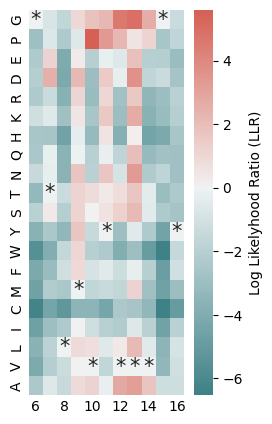

In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

#vcenter = 0
#vmin, vmax = ddG.values.min(), ddG.values.max()
#normalize = mcolors.TwoSlopeNorm(vcenter=vcenter, vmin=vmin, vmax=vmax)
#colormap = cm.RdBu

#sns.heatmap(data=ddG, norm=normalize, cmap=colormap)

#scalarmappaple = cm.ScalarMappable(norm=normalize, cmap=colormap)
#scalarmappaple.set_array(y)
#fig.colorbar(scalarmappaple)


fig, ax = plt.subplots(figsize=(2.5, 5))
#sns.heatmap(data=ddG, annot=labels, fmt="s", vmax=20, center= 0, cmap= 'coolwarm')
sns.heatmap(data=ddg, annot=labels, fmt="s", center= 0, cmap=sns.diverging_palette(200, 15, as_cmap=True), annot_kws={"size": 15}, cbar_kws={'label': 'Log Likelyhood Ratio (LLR)'})
plt.tick_params(length=0)
plt.show()

Gel analysis

In [ ]:
TMB2_17=[0.65846154,0.47955182,0.57517084,0.69384835,0.53078556,0.58448459,0.52761072,0.62807882,0.51882845]
o=[np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
V12T=[0.62141491,0.70843373,0.66064639,0.88419995,0.70137694,0.7112069,np.nan,np.nan,np.nan]
V10G=[0.73238095,0.5372549,0.53046595,0.5464684,None,None,None,None,None]
V12G=[0.7433414,0.76235855,0.59036145,0.62640449,0.55015198,None,None,None,None]
V10P=[0.85771812,0.67446662,0.79749104,0.65397924,None,None,None,None,None]
V12P=[0.46226415,0.50119142,0.51540914,0.50596421,0.62704726,0.66634708,None,None,None]
V10L=[0.48686211,0.51376147,0.4028103,None,None,None,None,None,None]

d = {'TMB2_17':TMB2_17,'V12T':V12T,'V10G':V10G,'V12G':V12G,'V10P':V10P,'V12P':V12P,'V10L':V10L}
df = pd.DataFrame(d)
df

,TMB2_17,V12T,V10G,V12G,V10P,V12P,V10L
0,0.658462,0.621415,0.732381,0.743341,0.857718,0.462264,0.486862
1,0.479552,0.708434,0.537255,0.762359,0.674467,0.501191,0.513761
2,0.575171,0.660646,0.530466,0.590361,0.797491,0.515409,0.402810
3,0.693848,0.884200,0.546468,0.626404,0.653979,0.505964,NaN
4,0.530786,0.701377,NaN,0.550152,NaN,0.627047,NaN
5,0.584485,0.711207,NaN,NaN,NaN,0.666347,NaN
6,0.527611,NaN,NaN,NaN,NaN,NaN,NaN
7,0.628079,NaN,NaN,NaN,NaN,NaN,NaN
8,0.518828,NaN,NaN,NaN,NaN,NaN,NaN


/tmp/ipython-input-11-1608011863.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.barplot(data=df, ci="sd",
/tmp/ipython-input-11-1608011863.py:3: FutureWarning: 

The `errcolor` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'color': 'black'}` instead.

  ax = sns.barplot(data=df, ci="sd",
/tmp/ipython-input-11-1608011863.py:3: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1.5}` instead.

  ax = sns.barplot(data=df, ci="sd",


<Axes: >

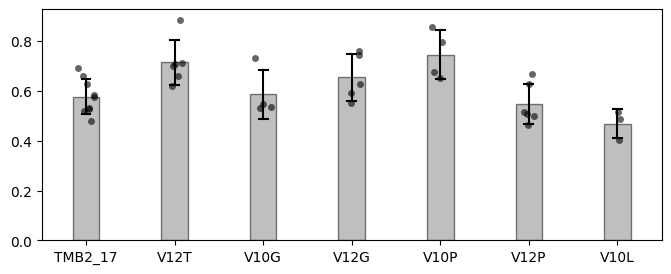

In [ ]:
plt.figure(figsize=(8,3))

ax = sns.barplot(data=df, ci="sd",
    edgecolor="black",
    errcolor="black",
    errwidth=1.5,
    capsize = 0.1,
    alpha=0.5, color="grey", width=0.3
)

sns.stripplot(data=df, dodge=False, alpha=0.6, ax=ax, color="black")

# remove extra legend handles
#handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles[2:], labels[2:], title='Smoker', bbox_to_anchor=(1, 1.02), loc='upper left')

In [ ]:
import numpy as np
from scipy import stats


TMB2_17=[0.65846154,0.47955182,0.57517084,0.69384835,0.53078556,0.58448459,0.52761072,0.62807882,0.51882845]
V12T=[0.62141491,0.70843373,0.66064639,0.88419995,0.70137694,0.7112069]
V10G=[0.73238095,0.5372549,0.53046595,0.5464684]
V12G=[0.7433414,0.76235855,0.59036145,0.62640449,0.55015198]
V10P=[0.85771812,0.67446662,0.79749104,0.65397924]
V12P=[0.46226415,0.50119142,0.51540914,0.50596421,0.62704726,0.66634708]
V10L=[0.48686211,0.51376147,0.4028103]

pV12T = stats.ttest_ind(TMB2_17, V12T, equal_var=False, nan_policy='omit')
pV12G = stats.ttest_ind(TMB2_17, V12G, equal_var=False, nan_policy='omit')
pV10P = stats.ttest_ind(TMB2_17, V10P, equal_var=False, nan_policy='omit')
pV12P = stats.ttest_ind(TMB2_17, V12P, equal_var=False, nan_policy='omit')
pV10L = stats.ttest_ind(TMB2_17, V10L, equal_var=False, nan_policy='omit')
p2V12P = stats.ttest_ind(V12T, V12P, equal_var=False, nan_policy='omit')
p3V12P = stats.ttest_ind(V10P, V12P, equal_var=False, nan_policy='omit')
p3V10L = stats.ttest_ind(V10L, V12P, equal_var=False, nan_policy='omit')

print(pV12T)
print(pV12G)
print(pV10P)
print(pV12P)
print(pV10L)
print(p2V12P)
print(p3V12P)
print(p3V10L)

TtestResult(statistic=np.float64(-3.134237867394125), pvalue=np.float64(0.011978665832378057), df=np.float64(9.037438484164857))
TtestResult(statistic=np.float64(-1.5982161917306326), pvalue=np.float64(0.15652479700965496), df=np.float64(6.612782994417077))
TtestResult(statistic=np.float64(-3.099848179759242), pvalue=np.float64(0.03110731826035498), df=np.float64(4.479841198470884))
TtestResult(statistic=np.float64(0.7649015948818971), pvalue=np.float64(0.4622544007260565), df=np.float64(9.854531778640325))
TtestResult(statistic=np.float64(2.6760013691214026), pvalue=np.float64(0.05207747506990916), df=np.float64(4.247704891759835))
TtestResult(statistic=np.float64(3.404799222790868), pvalue=np.float64(0.006830067022787992), df=np.float64(9.882713739075777))
TtestResult(statistic=np.float64(3.382539853187371), pvalue=np.float64(0.01626439935650694), df=np.float64(5.645405174175792))
TtestResult(statistic=np.float64(-1.6735349852056358), pvalue=np.float64(0.14832485391919167), df=np.flo

In [ ]:
import numpy as np
from scipy import stats

def box_and_whisker(data, title, ylabel, xticklabels):
    """
    Create a box-and-whisker plot with significance bars.
    """
    ax = plt.axes()
    bp = sns.boxplot(data, widths=0.6, patch_artist=True,color='grey')
    # Graph title
    ax.set_title(title, fontsize=14)
    # Label y-axis
    ax.set_ylabel(ylabel)
    # Label x-axis ticks
    ax.set_xticklabels(xticklabels)
    # Set y_limits
#    ax.set_ylim(0,1)
    # Hide x-axis major ticks
    ax.tick_params(axis='x', which='major', length=0)
    # Show x-axis minor ticks
    xticks = [0.5] + [x + 0.5 for x in ax.get_xticks()]
    ax.set_xticks(xticks, minor=True)
    # Clean up the appearance
    ax.tick_params(axis='x', which='minor', length=3, width=1)

#    # Change the colour of the boxes to Seaborn's 'pastel' palette
#    colors = sns.color_palette('pastel')
#    for patch, color in zip(bp['boxes'], colors):
#        patch.set_facecolor(color)

    # Colour of the median lines
 #   plt.setp(bp['medians'], color='k')

    # Check for statistical significance
    significant_combinations = []
    # Check from the outside pairs of boxes inwards
    ls = list(range(1, len(data) + 1))
    combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
    for c in combinations:
        data1 = data[c[0] - 1]
        data2 = data[c[1] - 1]
        # Significance
        U, p = stats.ttest_ind(data1, data2, equal_var=False, nan_policy='omit')
        if p < 0.05:
            significant_combinations.append([c, p])

    # Get info about y-axis
    bottom, top = ax.get_ylim()
    yrange = top - bottom

    # Significance bars
    for i, significant_combination in enumerate(significant_combinations):
        # Columns corresponding to the datasets of interest
        x1 = significant_combination[0][0]-1
        x2 = significant_combination[0][1]-1
        # What level is this bar among the bars above the plot?
        level = len(significant_combinations) - i
        # Plot the bar
        bar_height = (yrange * 0.08 * level) + top
        bar_tips = bar_height - (yrange * 0.02)
        plt.plot(
            [x1, x1, x2, x2],
            [bar_tips, bar_height, bar_height, bar_tips], lw=1, c='k')
        # Significance level
        p = significant_combination[1]
        if p < 0.001:
            sig_symbol = '***'
        elif p < 0.01:
            sig_symbol = '**'
        elif p < 0.05:
            sig_symbol = '*'
        text_height = bar_height + (yrange * 0.01)
        plt.text((x1 + x2) * 0.5, text_height, sig_symbol, ha='center', c='k')

    # Adjust y-axis
    bottom, top = ax.get_ylim()
    yrange = top - bottom
    ax.set_ylim(bottom - 0.02 * yrange, top)

    # Annotate sample size below each box
    for i, dataset in enumerate(data):
        d=[x for x in dataset if ~np.isnan(x)]
        print(d)
        sample_size = len(d)
        ax.text(i, bottom, fr'n = {sample_size}', ha='center', size='x-small')

    plt.show()


/tmp/ipython-input-13-3120160898.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels)


[np.float64(0.65846154), np.float64(0.47955182), np.float64(0.57517084), np.float64(0.69384835), np.float64(0.53078556), np.float64(0.58448459), np.float64(0.52761072), np.float64(0.62807882), np.float64(0.51882845)]
[np.float64(0.62141491), np.float64(0.70843373), np.float64(0.66064639), np.float64(0.88419995), np.float64(0.70137694), np.float64(0.7112069)]
[np.float64(0.73238095), np.float64(0.5372549), np.float64(0.53046595), np.float64(0.5464684)]
[np.float64(0.7433414), np.float64(0.76235855), np.float64(0.59036145), np.float64(0.62640449), np.float64(0.55015198)]
[np.float64(0.85771812), np.float64(0.67446662), np.float64(0.79749104), np.float64(0.65397924)]
[np.float64(0.46226415), np.float64(0.50119142), np.float64(0.51540914), np.float64(0.50596421), np.float64(0.62704726), np.float64(0.66634708)]
[np.float64(0.48686211), np.float64(0.51376147), np.float64(0.4028103)]


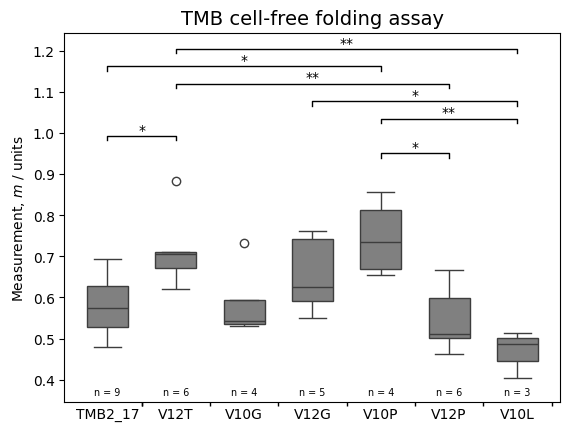

In [ ]:
data=[df[col].values for col in df.columns]
title = 'TMB cell-free folding assay'
ylabel = r'Measurement, $m$ / units'
xticklabels = ['TMB2_17','V12T','V10G','V12G','V10P','V12P','V10L']
box_and_whisker(data, title, ylabel, xticklabels)

In [ ]:
import numpy as np
from scipy import stats

def box_and_whisker(data, title, ylabel, xticklabels):
    """
    Create a box-and-whisker plot with significance bars.
    """
    ax = plt.axes()
    bp = sns.barplot(data=df, errorbar="sd", edgecolor="black",err_kws={'color': 'black', 'linewidth': 1.5},capsize = 0.1,alpha=0.5, color="grey", width=0.5)
    sns.stripplot(data=df, dodge=False, alpha=0.6, ax=ax, color="black")
    # Graph title
#    ax.set_title(title, fontsize=14)
    # Label y-axis
    ax.set_ylabel(ylabel, fontsize=13)
    # Label x-axis ticks
    ax.set_xticklabels(xticklabels, fontsize=12)
    # Set y_limits
#    ax.set_ylim(0,1)
    # Hide x-axis major ticks
    ax.tick_params(axis='x', which='major', length=0)
    # Show x-axis minor ticks
    xticks = [0.5] + [x + 0.5 for x in ax.get_xticks()]
    ax.set_xticks(xticks, minor=True)
    # Clean up the appearance
    ax.tick_params(axis='x', which='minor', length=3, width=1)

#    # Change the colour of the boxes to Seaborn's 'pastel' palette
#    colors = sns.color_palette('pastel')
#    for patch, color in zip(bp['boxes'], colors):
#        patch.set_facecolor(color)

    # Colour of the median lines
 #   plt.setp(bp['medians'], color='k')

    # Check for statistical significance
    significant_combinations = []
    # Check from the outside pairs of boxes inwards
    ls = list(range(1, len(data) + 1))
    combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
    for c in combinations:
        data1 = data[c[0] - 1]
        data2 = data[c[1] - 1]
        # Significance
        U, p = stats.ttest_ind(data1, data2, equal_var=False, nan_policy='omit')
        if p < 0.05:
            significant_combinations.append([c, p])

    # Get info about y-axis
    bottom, top = ax.get_ylim()
    yrange = top - bottom

    # Significance bars
    for i, significant_combination in enumerate(significant_combinations):
        # Columns corresponding to the datasets of interest
        x1 = significant_combination[0][0]-1
        x2 = significant_combination[0][1]-1
        # What level is this bar among the bars above the plot?
        level = len(significant_combinations) - i
        # Plot the bar
        bar_height = (yrange * 0.08 * level) + top
        bar_tips = bar_height - (yrange * 0.02)
        plt.plot(
            [x1, x1, x2, x2],
            [bar_tips, bar_height, bar_height, bar_tips], lw=1, c='k')
        # Significance level
        p = significant_combination[1]
        if p < 0.001:
            sig_symbol = '***'
        elif p < 0.01:
            sig_symbol = '**'
        elif p < 0.05:
            sig_symbol = '*'
        text_height = bar_height + (yrange * 0.01)
        plt.text((x1 + x2) * 0.5, text_height, sig_symbol, ha='center', c='k')

    # Adjust y-axis
    bottom, top = ax.get_ylim()
    yrange = top - bottom
    ax.set_ylim(bottom - 0.02 * yrange, top)

    # Annotate sample size below each box
#    for i, dataset in enumerate(data):
#        d=[x for x in dataset if ~np.isnan(x)]
#        print(d)
#        sample_size = len(d)
#        ax.text(i, bottom, fr'n = {sample_size}', ha='center', size='x-small')
    sns.despine()
    plt.show()


/tmp/ipython-input-20-2095251374.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=12)


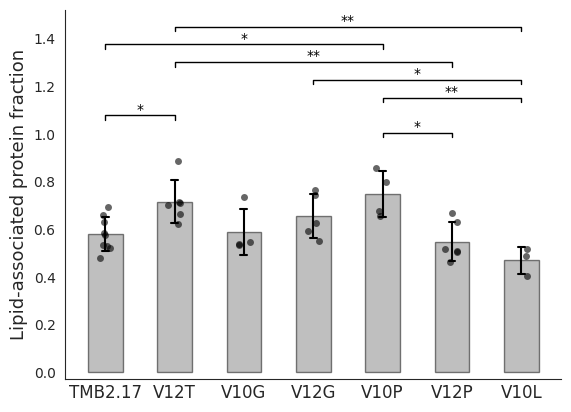

In [ ]:
data=[df[col].values for col in df.columns]
sns.set_style("white")
#title = 'TMB cell-free folding assay'
ylabel = r'Lipid-associated protein fraction'
xticklabels = ['TMB2.17','V12T','V10G','V12G','V10P','V12P','V10L']
box_and_whisker(data, title, ylabel, xticklabels)


In [ ]:
import numpy as np
from scipy import stats


TMB2_17b=[0.17031524,0.32125604,0.19854281,0.444444444,0.56932153,0.37060041,0.19171405,0.12723932,0.58663647]
V12Tb=[0.60850835,0.74320771,0.95571096,0.76965366,0.87429492,0.83827493]
V10Gb=[0.70304579,0.82367448,0.73550356,0.79726891]
V12Gb=[0.75955056,0.69090909,0.67100977,0.7976012,0.90293454,0.87839809]
V10Pb=[0.42105263,0.54880137,0.62162162,0.53067047]
#V12Pb=[0.46226415,0.50119142,0.51540914,0.50596421,0.62704726,0.66634708]
V10Lb=[0.51830986,0.62087912,0.57312253]

pV12Tb = stats.ttest_ind(TMB2_17b, V12Tb, equal_var=False, nan_policy='omit')
pV12Gb = stats.ttest_ind(TMB2_17b, V12Gb, equal_var=False, nan_policy='omit')
pV10Pb = stats.ttest_ind(TMB2_17b, V10Pb, equal_var=False, nan_policy='omit')
#pV12Pb = stats.ttest_ind(TMB2_17b, V12Pb, equal_var=False, nan_policy='omit')
pV10Lb = stats.ttest_ind(TMB2_17b, V10Lb, equal_var=False, nan_policy='omit')
#p2V12Pb = stats.ttest_ind(V12Tb, V12Pb, equal_var=False, nan_policy='omit')
#p3V12Pb = stats.ttest_ind(V10Pb, V12Pb, equal_var=False, nan_policy='omit')
#p3V10Lb = stats.ttest_ind(V10Lb, V12Pb, equal_var=False, nan_policy='omit')

print(pV12Tb)
print(pV12Gb)
print(pV10Pb)
#print(pV12Pb)
print(pV10Lb)
#print(p2V12Pb)
#print(p3V12Pb)
#print(p3V10Lb)

TtestResult(statistic=np.float64(-6.16193330571478), pvalue=np.float64(3.491676652008675e-05), df=np.float64(12.94006661687408))
TtestResult(statistic=np.float64(-6.490569957028115), pvalue=np.float64(2.2672967522994467e-05), df=np.float64(12.707206563244089))
TtestResult(statistic=np.float64(-2.80209646666643), pvalue=np.float64(0.017544231891716573), df=np.float64(10.760157102240806))
TtestResult(statistic=np.float64(-3.6870346868416113), pvalue=np.float64(0.004200053077193215), df=np.float64(9.996158711662439))


In [ ]:
import numpy as np
from scipy import stats

def box_and_whisker(data, title, ylabel, xticklabels):
    """
    Create a box-and-whisker plot with significance bars.
    """
    ax = plt.axes()
    bp = sns.boxplot(data, widths=0.6, patch_artist=True,color='grey')
    # Graph title
#    ax.set_title(title, fontsize=14)
    # Label y-axis
    ax.set_ylabel(ylabel, fontsize=14)
    # Label x-axis ticks
    ax.set_xticklabels(xticklabels, fontsize=14)
    # Set y_limits
#    ax.set_ylim(0,1)
    # Hide x-axis major ticks
    ax.tick_params(axis='x', which='major', length=0)
    # Show x-axis minor ticks
    xticks = [0.5] + [x + 0.5 for x in ax.get_xticks()]
    ax.set_xticks(xticks, minor=True)
    # Clean up the appearance
    ax.tick_params(axis='x', which='minor', length=3, width=1)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

#    # Change the colour of the boxes to Seaborn's 'pastel' palette
#    colors = sns.color_palette('pastel')
#    for patch, color in zip(bp['boxes'], colors):
#        patch.set_facecolor(color)

    # Colour of the median lines
 #   plt.setp(bp['medians'], color='k')

    # Check for statistical significance
    significant_combinations = []
    # Check from the outside pairs of boxes inwards
    ls = list(range(2, len(data) + 1))
#    combinations = [(ls[x], ls[x + y]) for y in reversed(ls) for x in range((len(ls) - y))]
    combinations = [(1, y) for y in ls]
    for c in combinations:
        print(c)
        data1 = data[c[0] - 1]
        data2 = data[c[1] - 1]
        # Significance
        U, p = stats.ttest_ind(data1, data2, equal_var=False, nan_policy='omit')
        if p < 0.05:
            significant_combinations.append([c, p])

    # Get info about y-axis
    bottom, top = ax.get_ylim()
    yrange = top - bottom

    # Significance bars
    for i, significant_combination in enumerate(significant_combinations):
        # Columns corresponding to the datasets of interest
        x1 = significant_combination[0][0]-1
        x2 = significant_combination[0][1]-1
        # What level is this bar among the bars above the plot?
        level = len(significant_combinations) - i
        # Plot the bar
        bar_height = (yrange * 0.08 * level) + top
        bar_tips = bar_height - (yrange * 0.02)
        plt.plot(
            [x1, x1, x2, x2],
            [bar_tips, bar_height, bar_height, bar_tips], lw=1, c='k')
        # Significance level
        p = significant_combination[1]
        if p < 0.001:
            sig_symbol = '***'
        elif p < 0.01:
            sig_symbol = '**'
        elif p < 0.05:
            sig_symbol = '*'
        text_height = bar_height + (yrange * 0.01)
        plt.text((x1 + x2) * 0.5, text_height, sig_symbol, ha='center', c='k')

    # Adjust y-axis
    bottom, top = ax.get_ylim()
    yrange = top - bottom
    ax.set_ylim(bottom - 0.02 * yrange, top)

    # Annotate sample size below each box
    for i, dataset in enumerate(data):
        d=[x for x in dataset if ~np.isnan(x)]
        print(d)
        sample_size = len(d)
        ax.text(i, bottom, fr'n = {sample_size}', ha='center', size=10)

    plt.show()


In [ ]:
TMB2_17b=[0.17031524,0.32125604,0.19854281,0.444444444,0.56932153,0.37060041,0.19171405,0.12723932,0.58663647]
o=[np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan]
V12Tb=[0.60850835,0.74320771,0.95571096,0.76965366,0.87429492,0.83827493,np.nan,np.nan,np.nan]
V10Gb=[0.73238095,0.5372549,0.53046595,0.5464684,None,None,None,None,None]
V12Gb=[0.75955056,0.69090909,0.67100977,0.7976012,0.90293454,0.87839809,None,None,None]
V10Pb=[0.42105263,0.54880137,0.62162162,0.53067047,None,None,None,None,None]
#V12Pb=[0.46226415,0.50119142,0.51540914,0.50596421,0.62704726,0.66634708,None,None,None]
#V10Lb=[0.51830986,0.62087912,0.57312253,None,None,None,None,None,None]

db = {'TMB2_17':TMB2_17b,'V12T':V12Tb,'V10G':V10Gb,'V12G':V12Gb,'V10P':V10Pb}
dfb = pd.DataFrame(db)
dfb

,TMB2_17,V12T,V10G,V12G,V10P
0,0.170315,0.608508,0.732381,0.759551,0.421053
1,0.321256,0.743208,0.537255,0.690909,0.548801
2,0.198543,0.955711,0.530466,0.671010,0.621622
3,0.444444,0.769654,0.546468,0.797601,0.530670
4,0.569322,0.874295,NaN,0.902935,NaN
5,0.370600,0.838275,NaN,0.878398,NaN
6,0.191714,NaN,NaN,NaN,NaN
7,0.127239,NaN,NaN,NaN,NaN
8,0.586636,NaN,NaN,NaN,NaN


(1, 2)
(1, 3)
(1, 4)
(1, 5)
[np.float64(0.17031524), np.float64(0.32125604), np.float64(0.19854281), np.float64(0.444444444), np.float64(0.56932153), np.float64(0.37060041), np.float64(0.19171405), np.float64(0.12723932), np.float64(0.58663647)]
[np.float64(0.60850835), np.float64(0.74320771), np.float64(0.95571096), np.float64(0.76965366), np.float64(0.87429492), np.float64(0.83827493)]
[np.float64(0.73238095), np.float64(0.5372549), np.float64(0.53046595), np.float64(0.5464684)]
[np.float64(0.75955056), np.float64(0.69090909), np.float64(0.67100977), np.float64(0.7976012), np.float64(0.90293454), np.float64(0.87839809)]
[np.float64(0.42105263), np.float64(0.54880137), np.float64(0.62162162), np.float64(0.53067047)]


/tmp/ipython-input-16-3052852035.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xticklabels, fontsize=14)


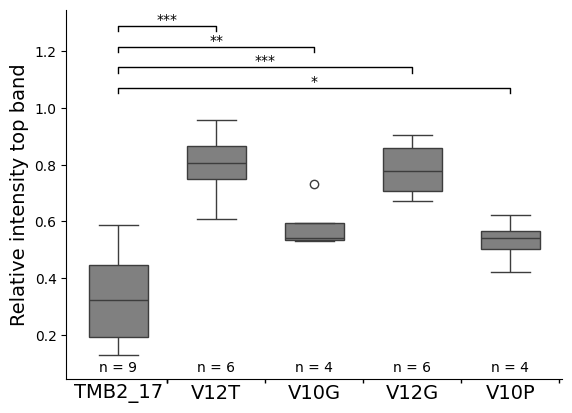

In [ ]:
data=[dfb[col].values for col in dfb.columns]
title = 'TMB cell-free folding assay'
ylabel = r'Relative intensity top band'
xticklabels = ['TMB2_17','V12T','V10G','V12G','V10P','V10L']
box_and_whisker(data, title, ylabel, xticklabels)